In [17]:
import os 
import pandas as pd 
import json
import numpy as np
initial_path = os.getcwd()

In [22]:
def create_results_csv(scenario_path, alpha=0.50, subscenarios=None, scenarios=None):
    if subscenarios is None:
        subscenarios = os.listdir(scenario_path)

    for subscenario in subscenarios:
        sub_path = os.path.join(scenario_path, subscenario)
        results_dir = os.path.join(sub_path, "Results")
        if not os.path.isdir(results_dir):
            continue

        all_configs_summary = []

        # Parcourt les sous-dossiers configs
        for config_folder in os.listdir(results_dir):

            # 👉 filtrage ici
            if scenarios is not None and config_folder not in scenarios:
                continue

            config_path = os.path.join(results_dir, config_folder)
            if not os.path.isdir(config_path):
                continue

            csv_files = [
                f for f in os.listdir(config_path)
                if f.startswith("scores_") and f.endswith(".csv")
            ]

            es_precision_list = []
            es_recall_list = []
            es_fscore_list = []
            execution_times = []
            dim_precision_list = []
            dim_recall_list = []
            dim_fscore_list = []
            metrics_map = {
        f'es-precision_{alpha}': es_precision_list,
        f'es-recall_{alpha}': es_recall_list,
        f'es-fscore_{alpha}': es_fscore_list,
        'time': execution_times,
        'es-dim-precision': dim_precision_list,
        'es-dim-recall': dim_recall_list,
        'es-dim-fscore': dim_fscore_list
    }
            for csv_file in csv_files:
                df = pd.read_csv(os.path.join(config_path, csv_file))
                for metric_name, lst in metrics_map.items():
                    values = df.loc[df['metric'] == metric_name, 'value']
                    lst.append(values.iloc[0] if not values.empty else 0)
            summary = {
                "config": config_folder,
                "precision_mean": np.mean(es_precision_list),
                "precision_std": np.std(es_precision_list),
                "recall_mean": np.mean(es_recall_list),
                "recall_std": np.std(es_recall_list),
                "fscore_mean": np.mean(es_fscore_list),
                "fscore_std": np.std(es_fscore_list),
                "dim_precision_mean": np.mean(dim_precision_list),
                "dim_precision_std": np.std(dim_precision_list),
                "dim_recall_mean": np.mean(dim_recall_list),
                "dim_recall_std": np.std(dim_recall_list),
                "dim_fscore_mean": np.mean(dim_fscore_list),
                "dim_fscore_std": np.std(dim_fscore_list),
                "time_mean": np.mean(execution_times),
                "time_std": np.std(execution_times),
            }

            all_configs_summary.append(summary)

        df_summary = pd.DataFrame(all_configs_summary)

        csv_path = os.path.join(sub_path, f"results_summary_threshold_{alpha}.csv")
        df_summary.to_csv(csv_path, index=False)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

methods_dict={'sDimMotifs_default':'sDimMotifs', 'mMotifs_non_overlap':'mMotifs', 'MatrixProfile_default': 'STOMP $(\mathbb{R}^d)$','UnivariateAfterPCA_MatrixProfile':'PCA+STOMP'}
color_palette = {
    'MatrixProfile_default': 'indigo',                 
    'UnivariateAfterPCA_MatrixProfile': 'orchid',     
    'sDimMotifs_default': 'royalblue',                
    'mMotifs_non_overlap': 'crimson'                 
}

marker_dict={'MatrixProfile':'H','PanMatrixProfile':'h','LocoMotif':'D','LatentMotif':'P','MDL':'^','Motiflets':'x','BasePersistentPattern':'s','Valmod':'p','Baseline':'+','AdaptativeBasePersistentPattern':'s','Grammarviz':'v' , 'Motiflets_numba':'x'}
marker_dict = {
    'MatrixProfile_default': 'H',
    'UnivariateAfterPCA_MatrixProfile': 'h',
    'sDimMotifs_default': 'D',
    'mMotifs_non_overlap': 'x'
}
metrics_dict={'es_fscore_0.5_mean' : 'Accuracy (fscore) average','es_fscore_0.5_std' : 'Accuracy (fscore) standard deviation ','es_precision_0.5_mean' : 'Accuracy (precision) average','es_precision_0.5_std' : 'Accuracy (precision) standard deviation','es_recall_0.5_mean' : 'Accuracy (recall) average','es_recall_0.5_std' : 'Accuracy (recall) standard deviation',  'execution_time_mean':'execution time average ','execution_time_std':'execution time standard deviation',
              'es_fscore_0.25_mean' : 'Accuracy (fscore) average','es_fscore_0.25_std' : 'Accuracy (fscore) standard deviation ','es_precision_0.25_mean' : 'Accuracy (precision) average','es_precision_0.25_std' : 'Accuracy (precision) standard deviation','es_recall_0.25_mean' : 'Accuracy (recall) average','es_recall_0.25_std' : 'Accuracy (recall) standard deviation',
              'es_fscore_0.75_mean' : 'Accuracy (fscore) average','es_fscore_0.75_std' : 'Accuracy (fscore) standard deviation ','es_precision_0.75_mean' : 'Accuracy (precision) average','es_precision_0.75_std' : 'Accuracy (precision) standard deviation','es_recall_0.75_mean' : 'Accuracy (recall) average','es_recall_0.75_std' : 'Accuracy (recall) standard deviation',
              'dim_fscore_mean' : 'Dimensionality accuracy (fscore) average','dim_fscore_std' : 'Dimensionality accuracy (fscore) standard deviation ','dim_precision_mean' : 'Dimensionality accuracy (precision) average','dim_precision_std' : 'Dimensionality accuracy (precision) standard deviation','dim_recall_mean' : 'Dimensionality accuracy (recall) average','dim_recall_std' : 'Dimensionality accuracy (recall) standard deviation'}


def plot_results_evolution(
    scenario_path, 
    thresholds=[0.5], 
    configs_to_plot=None,  # None pour toutes
    save_csv=True,         
    csv_name="all_results.csv",
    methods_dict=methods_dict,
    color_palette=color_palette,
    marker_dict=marker_dict,
    size_dict=None
):
    """
    Plot l'évolution des scores en fonction du paramètre variable.
    Les styles et labels sont définis via des dictionnaires.
    """

    all_data = []
    method_order = list(methods_dict.keys())
    for subscenario in os.listdir(scenario_path):
        sub_path = os.path.join(scenario_path, subscenario)
        if not os.path.isdir(sub_path):
            continue

        param_value = subscenario.split('_')[-1]
        try:
            param_value = float(param_value)
        except ValueError:
            pass

        for alpha in thresholds:
            csv_file = os.path.join(sub_path, f"results_summary_threshold_{alpha}.csv")
            if not os.path.exists(csv_file):
                continue

            df = pd.read_csv(csv_file)
            for _, row in df.iterrows():
                config = row["config"]
                if configs_to_plot is not None and config not in configs_to_plot:
                    continue

                all_data.append({
                    "config": config,
                    "param": param_value,
                    "threshold": alpha,
                    "precision_mean": row["precision_mean"],
                    "recall_mean": row["recall_mean"],
                    "fscore_mean": row["fscore_mean"],
                    "dim_precision_mean": row["dim_precision_mean"],
                    "dim_recall_mean": row["dim_recall_mean"],
                    "dim_fscore_mean": row["dim_fscore_mean"],
                    "time_mean": row["time_mean"],
                })

    all_df = pd.DataFrame(all_data)

    if save_csv and not all_df.empty:
        csv_path = os.path.join(scenario_path, csv_name)
        all_df.to_csv(csv_path, index=False)
        print(f"✅ CSV consolidé sauvegardé : {csv_path}")

    # ---------- Helpers ----------
    def get_label(cfg):
        return methods_dict.get(cfg, cfg) if methods_dict else cfg

    def get_color(cfg):
        return color_palette.get(cfg, None) if color_palette else None

    def get_marker(cfg):
        return marker_dict.get(cfg, 'o') if marker_dict else 'o'

    def get_size(cfg):
        return size_dict.get(cfg, 8) if size_dict else 8

    
    # ---------- Precision / Recall / F-score ----------
    for score in ["precision", "recall", "fscore"]:
        for alpha in thresholds:
            plt.figure(figsize=(14, 5))
            df_thr = all_df[all_df["threshold"] == alpha]

            for config in df_thr["config"].unique():
                df_config = df_thr[df_thr["config"] == config].sort_values("param")

                plt.plot(
                    df_config["param"],
                    df_config[f"{score}_mean"],
                    label=get_label(config),
                    color=get_color(config),
                    marker=get_marker(config),
                    markersize=get_size(config)
                )

            plt.xlabel("Paramètre variable")
            plt.ylabel(score)
            plt.title(f"{score.capitalize()} (threshold={alpha})")
            plt.legend()
            plt.grid(False)
            plt.tight_layout()
            plt.show()

    # ---------- Dim scores + time ----------
    for score in ["dim_precision", "dim_recall", "dim_fscore", "time"]:
        plt.figure(figsize=(14, 5))

        for config in all_df["config"].unique():
            df_config = all_df[all_df["config"] == config].sort_values("param")

            plt.plot(
                df_config["param"],
                df_config[f"{score}_mean"],
                label=get_label(config),
                color=get_color(config),
                marker=get_marker(config),
                markersize=get_size(config)
            )

        plt.xlabel("Paramètre variable")
        plt.ylabel(score)
        if score == "time":
            plt.yscale("log")

        plt.title(f"Évolution de {score}")
        plt.legend()
        plt.grid(False)
        plt.tight_layout()
        plt.show()



def plot_results_evolution_fused(
    scenario_path,
    thresholds=[0.5],
    metrics=("precision_mean", "recall_mean", "fscore_mean", "time_mean", "dim_precision_mean", "dim_recall_mean", "dim_fscore_mean"),
    configs_to_plot=None,
    xlabel="Paramètre variable",
    save_svg=True,
    svg_name="all_results.svg",
    methods_dict=methods_dict,
    color_palette=color_palette,
    marker_dict=marker_dict,
    size_dict=None
):
    """
    Charge les résultats depuis les sous-scénarios et trace l'évolution
    des métriques avec une mise en forme type plot_results_by_param_by_algo.
    """

    # ======================
    # 1) LOAD & CONSOLIDATE
    # ======================
    all_data = []
    handles, labels = None, None
    method_order = list(methods_dict.keys())
    for subscenario in os.listdir(scenario_path):
        sub_path = os.path.join(scenario_path, subscenario)
        if not os.path.isdir(sub_path):
            continue

        param_value = subscenario.split('_')[-1]
        try:
            param_value = float(param_value)
        except ValueError:
            pass

        for alpha in thresholds:
            csv_file = os.path.join(
                sub_path, f"results_summary_threshold_{alpha}.csv"
            )
            if not os.path.exists(csv_file):
                continue

            df = pd.read_csv(csv_file)
            for _, row in df.iterrows():
                config = row["config"]
                if configs_to_plot and config not in configs_to_plot:
                    continue

                entry = {
                    "config": config,
                    "param": param_value,
                    "threshold": alpha,
                }
                for col in df.columns:
                    if col.endswith("_mean"):
                        entry[col] = row[col]

                all_data.append(entry)

    all_df = pd.DataFrame(all_data)

    if all_df.empty:
        print("⚠️ Aucun résultat à tracer.")
        return

    # ======================
    # 2) HELPERS (STYLE)
    # ======================
    def label(cfg):
        return methods_dict.get(cfg, cfg) if methods_dict else cfg

    def color(cfg):
        return color_palette.get(cfg, None) if color_palette else None

    def marker(cfg):
        return marker_dict.get(cfg, 'o') if marker_dict else 'o'

    def msize(cfg):
        return size_dict.get(cfg, 8) / 1.7 if size_dict else 6

    # ======================
    # 3) PLOTS (BY THRESHOLD)
    # ======================
    for alpha in thresholds:
        df_thr = all_df[all_df["threshold"] == alpha]

        fig, axes = plt.subplots(
            len(metrics), 1,
            figsize=(8, 3 * len(metrics)),
            sharex=True
        )

        if len(metrics) == 1:
            axes = [axes]

        fig.suptitle(f"Results for alpha={alpha}", fontsize=16, y=0.95)

        for ax, metric in zip(axes, metrics):
            for cfg in method_order:
                if cfg not in df_thr["config"].values:
                    continue
                df_cfg = df_thr[df_thr["config"] == cfg].sort_values("param")

                ax.plot(
                    df_cfg["param"],
                    df_cfg[metric],
                    label=label(cfg),
                    color=color(cfg),
                    marker=marker(cfg),
                    markersize=msize(cfg)
                )

            if metric == "time_mean":
                ax.set_yscale("log")
            if metric == "fscore_mean":
                ax.set_ylabel("Temporal accuracy (fscore)")
            elif metric == "dim_fscore_mean":
                ax.set_ylabel("Dimensional accuracy (fscore)")
            else:
                ax.set_ylabel(metric.replace("_mean", ""))
            ax.set_xlabel(xlabel)
            

            '''ax.legend(
                loc="upper center",
                ncol=4,
                bbox_to_anchor=(0.5, 1.2),
            )'''
            #ax.set_xticks(df_cfg["param"])
            #ax.set_xticklabels(df_cfg["param"])
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        if save_svg and not all_df.empty:
            svg_path = os.path.join(scenario_path, svg_name)
            plt.savefig(svg_path, format="svg", bbox_inches="tight")
            print(f"✅ Figure SVG sauvegardée : {svg_path}")
        plt.show()


## Number of motifs

In [ ]:
scenario_path = initial_path+'/../multivariate_benchmark/synthetic/number_of_motifs'
for alpha in [0.25, 0.50, 0.75]:
    create_results_csv(scenario_path, alpha=alpha)

/Users/valerio/anaconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/valerio/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/valerio/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/valerio/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/valerio/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/valerio/anaconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: Runt

In [117]:
configs_to_plot = ['mStamp_MP_reworked_extended','mMotifs_non_overlap','UnivariateAfterPCA_MatrixProfile','MatrixProfile_default']

✅ Figure SVG sauvegardée : /Users/valerio/Documents/Borelli/These/Subdimensional Motifs /experiments/../multivariate_benchmark/synthetic/number_of_motifs_2/n_motifs_results.svg


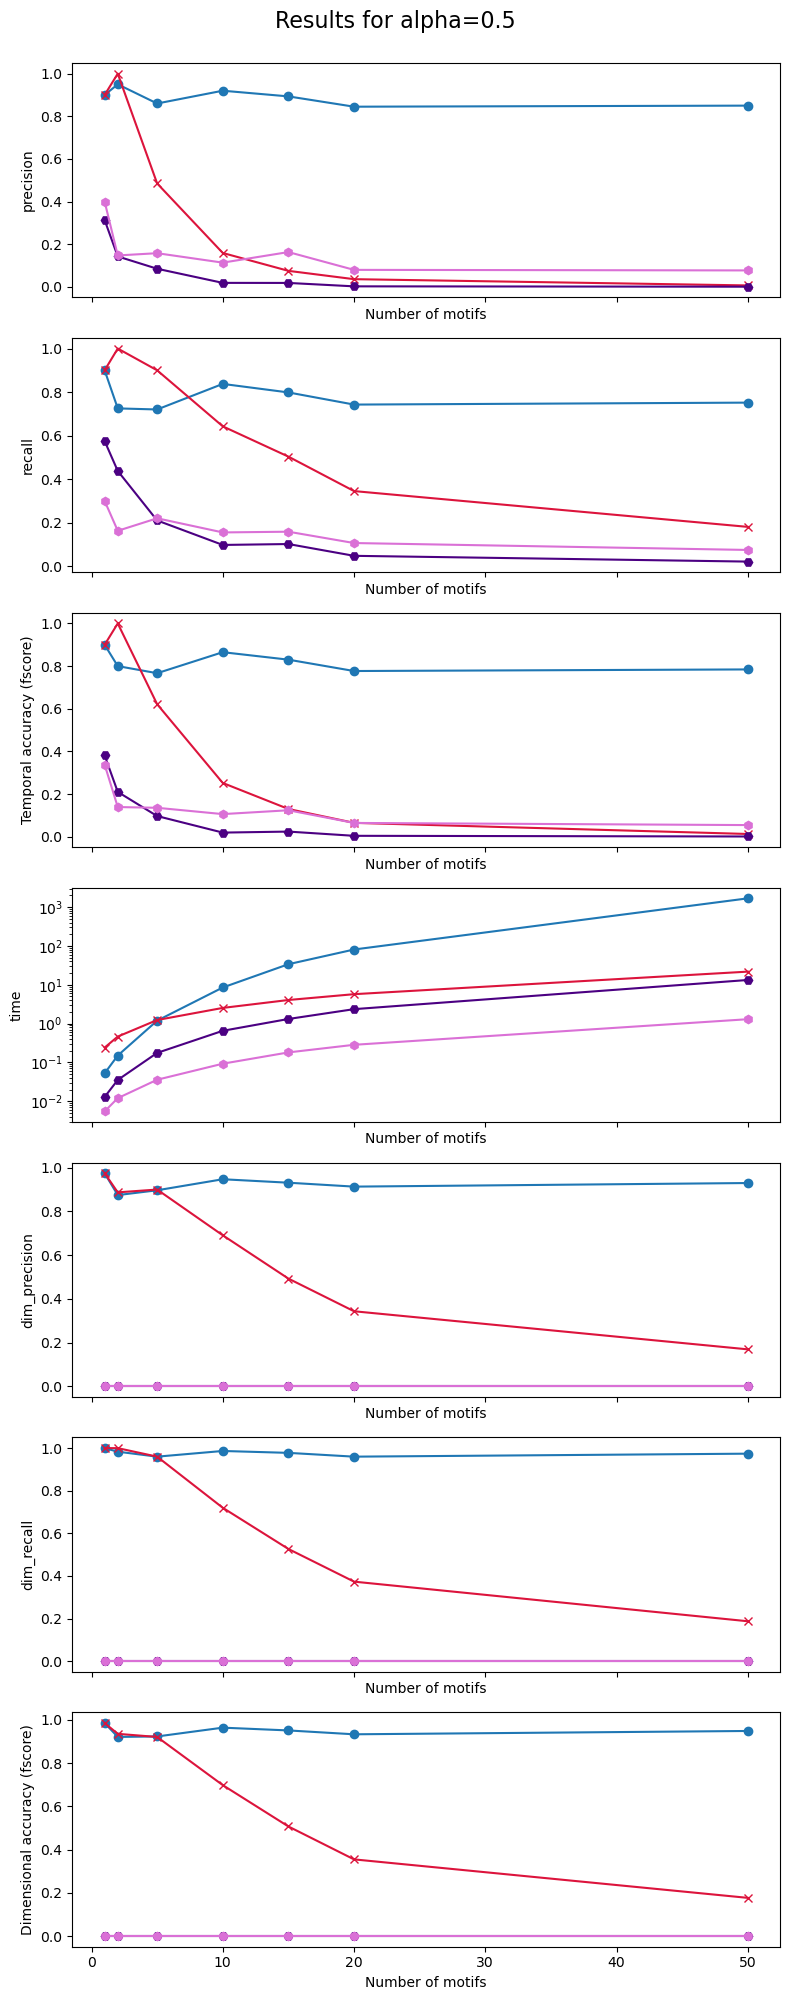

In [125]:
plot_results_evolution_fused(scenario_path,thresholds=[0.5],configs_to_plot=configs_to_plot, xlabel = 'Number of motifs', save_svg=True,svg_name="n_motifs_results.svg")